=== TASK 1: CLUSTERING ANALYSIS ===
=== DATA PREPROCESSING ===
1. Data loaded. Shape: (6340, 219)
2. Data cleaned. New shape: (6340, 219)
3. Data standardized

=== DATA SPLITTING ===
Data split complete - Train: 3804, Eval: 1268, Test: 1268

=== MODEL IMPLEMENTATION ===
Implemented models: KMeans and Hierarchical Clustering

=== MODEL TUNING ===
K=2: Silhouette Score = 0.012
K=3: Silhouette Score = 0.014
K=4: Silhouette Score = 0.026
K=5: Silhouette Score = 0.017

Optimal clusters: k=4 (score: 0.026)

Evaluating KMeans...

=== MODEL EVALUATION ===
Silhouette Score: 0.034
Davies-Bouldin Index: 2.816


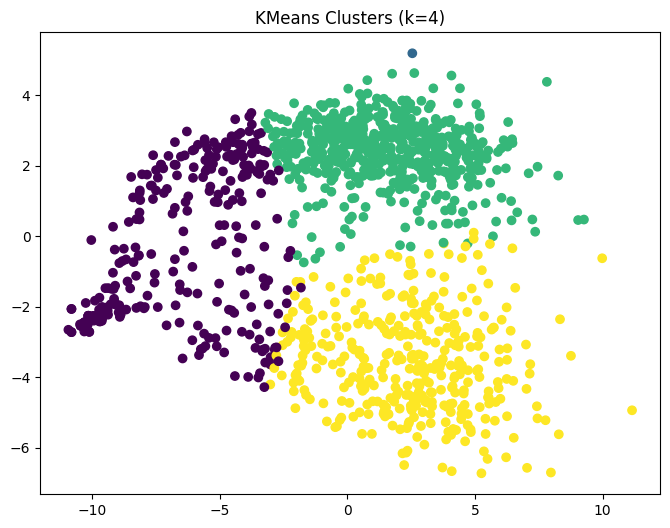


Evaluating Hierarchical...

=== MODEL EVALUATION ===
Silhouette Score: 0.028
Davies-Bouldin Index: 1.659


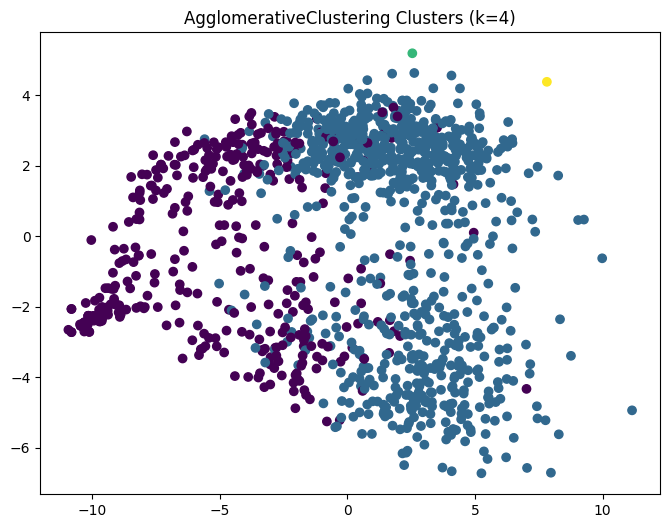


Results saved to clustering_results.csv


In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

def load_and_preprocess():
    """Requirement 1: Data Preprocessing"""
    print("=== DATA PREPROCESSING ===")
    try:
        # Load data
        df = pd.read_csv('/kaggle_Interests_group.csv')
        print("1. Data loaded. Shape:", df.shape)

        # Clean data
        df = df.replace(r'^\s*$', np.nan, regex=True)
        for col in df.columns[2:]:
            df[col] = df[col].apply(lambda x: 1 if str(x).strip().lower() in ['t', '1', '1.0'] else 0)

        # Remove non-varying features
        df = df.loc[:, (df != df.iloc[0]).any()]
        print("2. Data cleaned. New shape:", df.shape)

        # Handle missing values
        imputer = SimpleImputer(strategy='constant', fill_value=0)
        X = imputer.fit_transform(df.iloc[:, 2:])

        # Standardize data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print("3. Data standardized")

        return X_scaled, df.iloc[:, 0].values if 'group' in df.columns else None

    except Exception as e:
        print("Preprocessing failed:", str(e))
        return None, None

def split_data(X):
    """Requirement 2: Data Splitting"""
    print("\n=== DATA SPLITTING ===")
    # Split into train (60%), eval (20%), test (20%)
    X_train, X_temp = train_test_split(X, test_size=0.4, random_state=42)
    X_eval, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)
    print(f"Data split complete - Train: {len(X_train)}, Eval: {len(X_eval)}, Test: {len(X_test)}")
    return X_train, X_eval, X_test

def implement_models():
    """Requirement 3: Model Implementation"""
    print("\n=== MODEL IMPLEMENTATION ===")
    models = {
        'KMeans': KMeans(n_init=20, random_state=42),
        'Hierarchical': AgglomerativeClustering(metric='euclidean', linkage='ward')
    }
    print("Implemented models: KMeans and Hierarchical Clustering")
    return models

def train_model(model, X_train, k):
    """Requirement 4: Model Training"""
    print(f"\nTraining {type(model).__name__} with k={k}...")
    if hasattr(model, 'n_clusters'):
        model.set_params(n_clusters=k)
    return model.fit_predict(X_train)

def tune_model(X_train, X_eval):
    """Requirement 5: Model Tuning"""
    print("\n=== MODEL TUNING ===")
    # Find optimal k (2-5) using evaluation set
    best_k = 2
    best_score = -1

    for k in range(2, 6):
        kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
        labels = kmeans.fit_predict(X_eval)
        score = silhouette_score(X_eval, labels)
        print(f"K={k}: Silhouette Score = {score:.3f}")

        if score > best_score:
            best_k = k
            best_score = score

    print(f"\nOptimal clusters: k={best_k} (score: {best_score:.3f})")
    return best_k

def evaluate_model(model, X_test, k):
    """Requirement 6: Model Evaluation"""
    print("\n=== MODEL EVALUATION ===")
    if hasattr(model, 'n_clusters'):
        model.set_params(n_clusters=k)

    labels = model.fit_predict(X_test)

    # Calculate metrics
    sil_score = silhouette_score(X_test, labels)
    db_score = davies_bouldin_score(X_test, labels)

    print(f"Silhouette Score: {sil_score:.3f}")
    print(f"Davies-Bouldin Index: {db_score:.3f}")

    # Visualize clusters
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
    plt.title(f'{type(model).__name__} Clusters (k={k})')
    plt.show()

    return labels

def main():
    print("=== TASK 1: CLUSTERING ANALYSIS ===")

    # 1. Data Preprocessing
    X_scaled, original_groups = load_and_preprocess()
    if X_scaled is None:
        return

    # 2. Data Splitting
    X_train, X_eval, X_test = split_data(X_scaled)

    # 3. Model Implementation
    models = implement_models()

    # 4-5. Model Training & Tuning
    best_k = tune_model(X_train, X_eval)

    # 6. Evaluation for each model
    results = {}
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        labels = evaluate_model(model, X_test, best_k)
        results[name] = labels

    # Save results
    results_df = pd.DataFrame({
        'Original_Group': original_groups[:len(X_test)],
        **{f'{k}_Cluster': v for k,v in results.items()}
    })
    results_df.to_csv('clustering_results.csv', index=False)
    print("\nResults saved to clustering_results.csv")

if __name__ == "__main__":
    main()